In [12]:
import torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pandas import read_csv
from torch import Tensor
from tqdm import trange

from datasets import CubeObstacle, CylinderObstacle
from utils.tools import calc_sig_strength_gpu
from utils.config import Hyperparameters as hp

random_seed = 42

In [13]:
# define the obstacles

# Create obstacles and convert to torch tensors

torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

obstacle_ls = [
    CubeObstacle(-30, 25, 35, 60, 20, 0.1),
    CubeObstacle(-30, -25, 45, 10, 35, 0.1),
    CubeObstacle(-30, -60, 35, 60, 20, 0.1),
    CubeObstacle(50, -20, 35, 25, 25, 0.1),
    CylinderObstacle(10, -5,  70, 15, 0.1),
]

obst_points = []
for obstacle in obstacle_ls:
    obst_points.append(torch.tensor(obstacle.points, dtype=torch.float32))

obst_points = torch.cat([op for op in obst_points], dim=1).mT.to(hp.device)

In [7]:
def brute_force_blockage(gn_tensor: Tensor, height: float = 70, chunk_size: int = 1000, device: str = 'cpu'):
    x = torch.arange(-100, 100.01, 0.01, device=device)
    y = torch.arange(-100, 100.01, 0.01, device=device)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    Z = torch.full_like(X, height, device=device)
    grid = torch.stack([X, Y, Z], dim=-1)
    n, m, _ = grid.shape

    results = []

    for i in trange(0, n, chunk_size):
        grid_chunk = grid[i: i + chunk_size].reshape(-1, 3)
        result_se = calc_sig_strength_gpu(grid_chunk, gn_tensor, obst_points)
        results.append(result_se.cpu())

    result_se = torch.cat(results, dim=0)
    return result_se

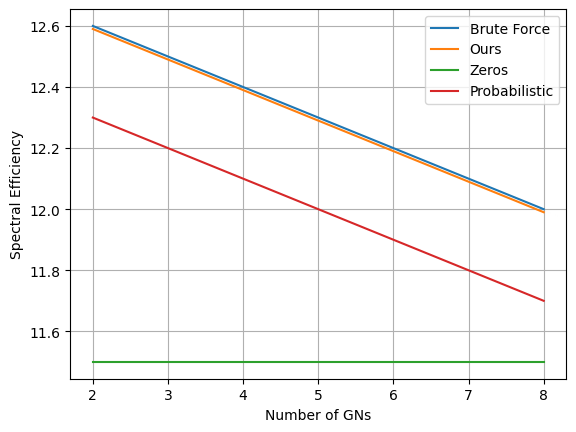

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# x축 값을 2부터 8까지 생성 (길이 7)
x = np.arange(2, 9)

brute_force = np.array([12.6, 12.5, 12.4, 12.3, 12.2, 12.1, 12])
ours = np.array([12.59, 12.49, 12.39, 12.29, 12.19, 12.09, 11.99])
zeros = np.array([11.5, 11.5, 11.5, 11.5, 11.5, 11.5, 11.5])
prob = np.array([12.3, 12.2, 12.1, 12.0, 11.9, 11.8, 11.7])

plt.plot(x, brute_force, label='Brute Force')
plt.plot(x, ours, label='Ours')
plt.plot(x, zeros, label='Zeros')
plt.plot(x, prob, label='Probabilistic')

plt.xlabel('Number of GUs')
plt.ylabel('Spectral Efficiency')
plt.legend()
plt.grid()
plt.show()


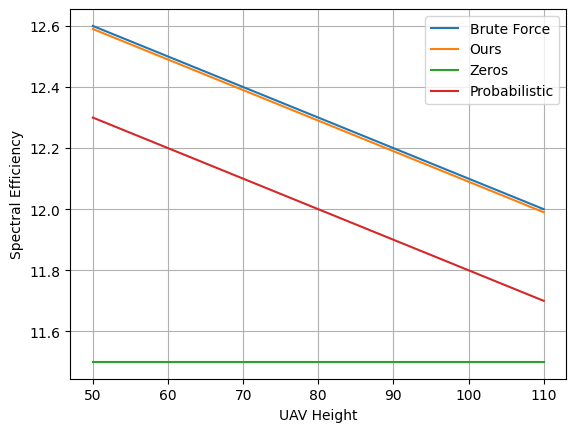

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# x축 값을 2부터 8까지 생성 (길이 7)
x = np.arange(50, 120, 10)

brute_force = np.array([12.6, 12.5, 12.4, 12.3, 12.2, 12.1, 12])
ours = np.array([12.59, 12.49, 12.39, 12.29, 12.19, 12.09, 11.99])
zeros = np.array([11.5, 11.5, 11.5, 11.5, 11.5, 11.5, 11.5])
prob = np.array([12.3, 12.2, 12.1, 12.0, 11.9, 11.8, 11.7])

plt.plot(x, brute_force, label='Brute Force')
plt.plot(x, ours, label='Ours')
plt.plot(x, zeros, label='Zeros')
plt.plot(x, prob, label='Probabilistic')

plt.xlabel('UAV Height')
plt.ylabel('Spectral Efficiency')
plt.legend()
plt.grid()
plt.show()

In [3]:
import pandas as pd

df = pd.read_csv('matlab/data/test.csv')
df.head()

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50


In [4]:
df['prob_x'] = None
df['prob_y'] = None
df['prob_z'] = 50

df.loc[0, 'prob_x'] = 1
df.head()

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50,1,None,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50,None,None,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50,None,None,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50,None,None,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50,None,None,50


In [5]:
import numpy as np
import torch
from utils.config import Hyperparameters as hp

gn_sets = df[['gnd1_x', 'gnd1_y', 'gnd1_z',
              'gnd2_x', 'gnd2_y', 'gnd2_z',
              'gnd3_x', 'gnd3_y', 'gnd3_z',
              'gnd4_x', 'gnd4_y', 'gnd4_z',]].values
gn_tensor = torch.tensor(gn_sets.reshape(-1, 4, 3), device=hp.device, dtype=torch.float32)
gn_tensor.shape

torch.Size([20000, 4, 3])

In [34]:
from utils.tools import probabilistic_channel_model

sig = probabilistic_channel_model(gn_tensor[0], height=50, device=hp.device)

In [37]:
max_idx = torch.unravel_index(torch.argmax(sig), sig.shape)
np_max_pos = np.array((max_idx[0].cpu().numpy()/10-100, max_idx[1].cpu().numpy()/10-100, 50))
np_max_pos

array([-56.8,  36.9,  50. ])

In [40]:
from tqdm import trange
for i in trange(gn_tensor.shape[0]):
    sig = probabilistic_channel_model(gn_tensor[i], height=50, device=hp.device)
    max_idx = torch.unravel_index(torch.argmax(sig), sig.shape)
    np_max_pos = np.array((max_idx[0].cpu().numpy()/10-100, max_idx[1].cpu().numpy()/10-100, 50))
    df.loc[i, 'prob_x'] = np_max_pos[0]
    df.loc[i, 'prob_y'] = np_max_pos[1]


100%|██████████| 20000/20000 [21:28<00:00, 15.52it/s]


In [41]:
df

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,gnd4_y,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,43.005120,0.0,-57.3,36.1,50,-56.8,36.9,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,-17.990965,0.0,-84.7,-60.9,50,-35.0,-39.5,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,39.862230,0.0,73.4,-67.8,50,46.3,-36.5,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,-78.762474,0.0,-41.4,-66.4,50,-43.1,0.1,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,-27.882648,0.0,55.6,-35.6,50,42.8,-19.8,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11.638821,71.111550,0.0,-93.879070,-29.168350,0.0,-79.655690,22.396015,0.0,-97.787056,-87.557274,0.0,-82.8,27.7,50,-83.7,-16.1,50
19996,-37.095936,-57.266000,0.0,-48.459373,-82.493340,0.0,-86.387110,28.871881,0.0,71.292480,58.005860,0.0,-42.0,-47.7,50,-42.4,-53.0,50
19997,-74.150140,17.290460,0.0,-87.623955,24.137222,0.0,-99.010700,-85.986050,0.0,65.995370,35.097740,0.0,-76.6,-17.8,50,-75.8,12.1,50
19998,-69.548004,-65.976360,0.0,52.309345,92.118360,0.0,-22.532833,89.638090,0.0,98.607730,13.356745,0.0,-25.7,91.6,50,33.3,72.2,50


In [44]:
df['centroid_x'] = (df['gnd1_x'] + df['gnd2_x'] + df['gnd3_x'] + df['gnd4_x'])/4
df['centroid_y'] = (df['gnd1_y'] + df['gnd2_y'] + df['gnd3_y'] + df['gnd4_y'])/4
df['centroid_z'] = df['result_z']
df

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,gnd3_x,gnd3_y,gnd3_z,gnd4_x,...,gnd4_z,result_x,result_y,result_z,prob_x,prob_y,prob_z,centroid_x,centroid_y,centroid_z
0,-95.918290,-74.374344,0.0,-46.555717,58.980034,0.0,-81.410740,27.057886,0.0,-37.985687,...,0.0,-57.3,36.1,50,-56.8,36.9,50,-65.467608,13.667174,50
1,-17.681240,-65.151085,0.0,-10.164696,98.798200,0.0,-42.650750,-53.216180,0.0,-44.527350,...,0.0,-84.7,-60.9,50,-35.0,-39.5,50,-28.756009,-9.390007,50
2,58.891796,-20.107973,0.0,-58.255870,-96.220634,0.0,33.647717,-75.661380,0.0,93.381370,...,0.0,73.4,-67.8,50,46.3,-36.5,50,31.916253,-38.031939,50
3,-33.573128,23.163855,0.0,-60.078380,-88.839455,0.0,-64.322655,21.590387,0.0,20.764374,...,0.0,-41.4,-66.4,50,-43.1,0.1,50,-34.302447,-30.711922,50
4,-48.722970,40.294624,0.0,43.946850,-53.508945,0.0,11.003971,59.308410,0.0,72.582436,...,0.0,55.6,-35.6,50,42.8,-19.8,50,19.702572,4.552860,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,11.638821,71.111550,0.0,-93.879070,-29.168350,0.0,-79.655690,22.396015,0.0,-97.787056,...,0.0,-82.8,27.7,50,-83.7,-16.1,50,-64.920749,-5.804515,50
19996,-37.095936,-57.266000,0.0,-48.459373,-82.493340,0.0,-86.387110,28.871881,0.0,71.292480,...,0.0,-42.0,-47.7,50,-42.4,-53.0,50,-25.162485,-13.220400,50
19997,-74.150140,17.290460,0.0,-87.623955,24.137222,0.0,-99.010700,-85.986050,0.0,65.995370,...,0.0,-76.6,-17.8,50,-75.8,12.1,50,-48.697356,-2.365157,50
19998,-69.548004,-65.976360,0.0,52.309345,92.118360,0.0,-22.532833,89.638090,0.0,98.607730,...,0.0,-25.7,91.6,50,33.3,72.2,50,14.709059,32.284209,50


In [45]:
df.to_csv('matlab/data/test_v2.csv', index=False)

In [32]:
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from model import Net
from datasets import TrainDataset
from tqdm import tqdm


torch.manual_seed(random_seed)
np.random.seed(random_seed)
if hp.device == "cuda":
    torch.cuda.manual_seed_all(random_seed)

model = Net(4*2, 1024, 4, output_N=2).to(hp.device)

model.load_state_dict(torch.load('models/height_test/best_height_50_epoch_9735.pt', map_location=hp.device, weights_only=True))

x = gn_tensor[:, :, :2].reshape(-1, 2*4)

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_x.fit(np.ones((2, x.shape[1]), dtype=np.float32)*np.array([[-100, 100]]).mT)
x_scaled = scaler_x.transform(x.cpu().numpy())

test_dataset = TrainDataset(x_scaled, dtype=torch.float32).to(hp.device)
test_dataloader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [37]:
result = []

with torch.no_grad():
    for x in tqdm(test_dataloader):
        y_pred = model(x)
        result.append(y_pred)

result = torch.cat(result, dim=0)
result = torch.hstack((result.cpu()* hp.area_size - hp.area_size / 2, torch.ones(result.shape[0], 1, device='cpu') * 0.5))
result

100%|██████████| 20/20 [00:00<00:00, 156.30it/s]


tensor([[-100.0000,  100.0000,    0.5000],
        [ -99.9998,  -16.6216,    0.5000],
        [ 100.0000, -100.0000,    0.5000],
        ...,
        [-100.0000,  100.0000,    0.5000],
        [ -44.2280,    9.9913,    0.5000],
        [ 100.0000,  -99.9999,    0.5000]])